<a href="https://colab.research.google.com/github/Nunomota1/Audio_Assignment_2/blob/main/audio_assignement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AUDIO ASSIGNMENT

# 1

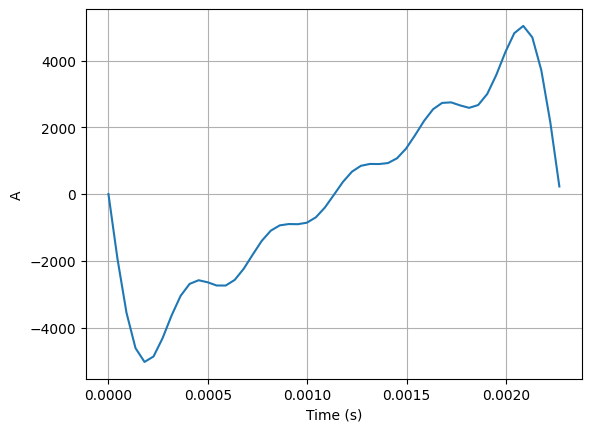

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do problema
# Aqui definimos a identidade da onda: amplitude, frequência
A = 5000
F = 440
T = 1 / F
Fs = 22050

time = np.arange(0, T, 1 / Fs)

x = np.zeros(len(time))

for k in range(1,6):
    x += - (((2*A)/(np.pi * k)) * np.sin(2 * np.pi * F * k * time))

plt.figure()
plt.plot(time, x)
plt.title("")
plt.xlabel("Time (s)")
plt.ylabel("A")
plt.grid()
plt.show()

# 2



In [2]:
import numpy as np
import matplotlib.pyplot as plt

def geranota(nota, duracao, Fs):

    T0 = 1.0 / (440.0 * nota)
    A = 5000

    # Time vector for the full duration
    t = np.arange(0, duracao, 1.0 / Fs)
    amostras = np.zeros(len(t))

    # Waveform synthesis using the first 5 terms of the summation

    F = 1.0 / T0
    for k in range(1, 6):
        amostras += -(2.0 * A / (np.pi * k)) * np.sin(2.0 * np.pi * k * F * t)

    # Fade-in and fade-out using the first quarter-period of a sine:
    # smooth ramp 0 -> 1 over the first 1/10, and 1 -> 0 over the last 1/10.
    N = len(amostras)
    L = N // 10
    if L > 0:
        ramp = np.sin(np.linspace(0, np.pi / 2, L))
        amostras[:L]  *= ramp
        amostras[-L:] *= ramp[::-1]

    return amostras


### Testing the function

Generating an LA4 note (`nota = 1.0`) with 500 ms duration to visualise the fade-in and fade-out effect.

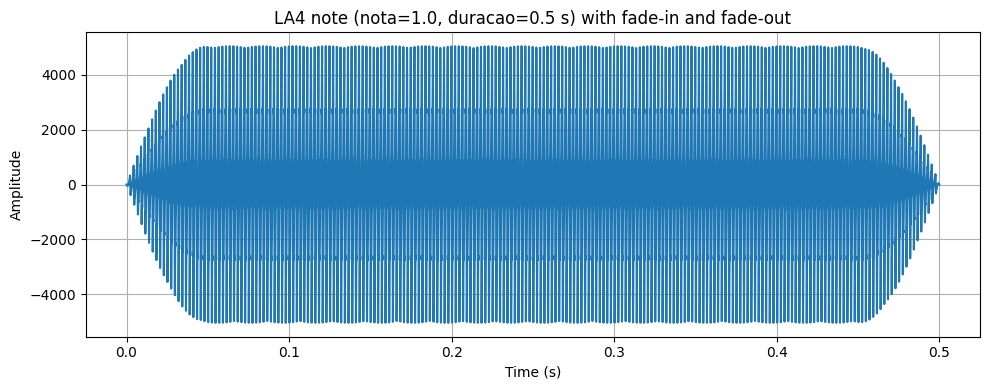

In [3]:
Fs = 22050
y = geranota(1.0, 0.5, Fs)

t_axis = np.arange(len(y)) / Fs

plt.figure(figsize=(10, 4))
plt.plot(t_axis, y)
plt.title("LA4 note (nota=1.0, duracao=0.5 s) with fade-in and fade-out")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.tight_layout()
plt.show()


# **3**

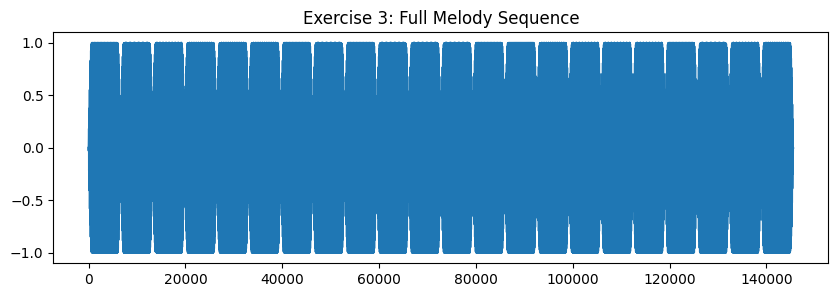

In [5]:
from IPython.display import Audio

# do  = 2**(-9/12)
# re  = 2**(-7/12)
# mi  = 2**(-5/12)
# fa  = 2**(-4/12)
# sol = 2**(-2/12)
# la  = 2**(0/12)

Fs = 22050

multipliers = [2**(-9/12), 2**(-7/12), 2**(-5/12), 2**(-4/12), 2**(-4/12), 2**(-4/12), 2**(-9/12), 2**(-7/12), 2**(-9/12), 2**(-7/12), 2**(-7/12), 2**(-7/12),
               2**(-9/12), 2**(-2/12), 2**(-4/12), 2**(-5/12), 2**(-5/12), 2**(-5/12), 2**(-9/12), 2**(-7/12), 2**(-5/12), 2**(-4/12)]
# pauta = [do re mi fa fa fa do re do re re re do sol fa mi mi mi do re mi fa]

melodia_completa = np.concatenate([geranota(m, 0.3, Fs) for m in multipliers])

melodia = melodia_completa / np.max(np.abs(melodia_completa))

# Visualize the result
plt.figure(figsize=(10, 3))
plt.plot(melodia)
plt.title("Exercise 3: Full Melody Sequence")
plt.show()

# Play the audio
Audio(melodia, rate=Fs)

# 4

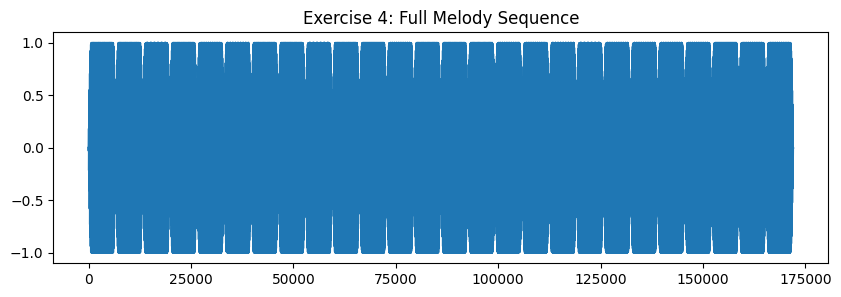

In [6]:
Fs = 22050

multipliers = [
    2**(-9/12), 2**(-9/12), 2**(-7/12), 2**(-9/12), 2**(-4/12), 2**(-5/12),
    2**(-9/12), 2**(-9/12), 2**(-7/12), 2**(-9/12), 2**(-2/12), 2**(-4/12),
    2**(-9/12), 2**(-9/12), 2**(3/12),
    2**(0/12), 2**(-4/12), 2**(-5/12), 2**(-7/12),
    2**(0/12), 2**(0/12), 2**(0/12), 2**(-4/12), 2**(-2/12), 2**(-4/12), 2**(-4/12)
]
# pauta = [do re mi fa fa fa do re do re re re do sol fa mi mi mi do re mi fa]

melodia_completa = np.concatenate([geranota(m, 0.3, Fs) for m in multipliers])

melodia = melodia_completa / np.max(np.abs(melodia_completa))

# Visualize the result
plt.figure(figsize=(10, 3))
plt.plot(melodia)
plt.title("Exercise 4: Full Melody Sequence")
plt.show()

# Play the audio
Audio(melodia, rate=Fs)